# 24AI636 - Mini Project 3: Autoencoder + WGAN

In [3]:
pip install -v -r requirements.txt


Using pip 26.0.1 from d:\Amritha\Deep Learning - 4\SCAFFOLD_R3\DLR3\Lib\site-packages\pip (python 3.11)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
print(torch.__version__)

2.3.0+cu121


In [5]:
import config
config.print_config()

  Mini Project 3 Configuration (LOCAL)
Device       : cuda
Data Root    : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
Image Size   : 64x64
AE Latent    : 128d | Epochs: 5
GAN Noise    : 128d | Epochs: 5
Checkpoints  : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\checkpoints
Outputs      : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs
  Mini Project 3 Configuration (LOCAL)
Device       : cuda
Data Root    : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
Image Size   : 64x64
AE Latent    : 128d | Epochs: 5
GAN Noise    : 128d | Epochs: 5
Checkpoints  : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\checkpoints
Outputs      : D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs


In [6]:
from dataset import get_dataloader

loader, dataset = get_dataloader(batch_size=16, max_images=200)

[Dataset] Loaded 200 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 12 | Batch size: 16


In [7]:
from models import Autoencoder, Generator, Critic

[Dataset] Loaded 61827 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 966 | Batch size: 64

Starting Autoencoder Training...



Epoch [1/5]: 100%|██████████| 966/966 [02:37<00:00,  6.13it/s, loss=0.0379]


Epoch [1] Loss: 0.0700


Epoch [2/5]: 100%|██████████| 966/966 [00:29<00:00, 32.28it/s, loss=0.0255]


Epoch [2] Loss: 0.0285


...

Epoch [3] Loss: 0.0211


Epoch [4/5]: 100%|██████████| 966/966 [00:31<00:00, 30.91it/s, loss=0.0182]


Epoch [4] Loss: 0.0179


Epoch [5/5]: 100%|██████████| 966/966 [00:32<00:00, 29.66it/s, loss=0.0151]


Epoch [5] Loss: 0.0158

Training Complete.
Final model saved: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\checkpoints\autoencoder.pth


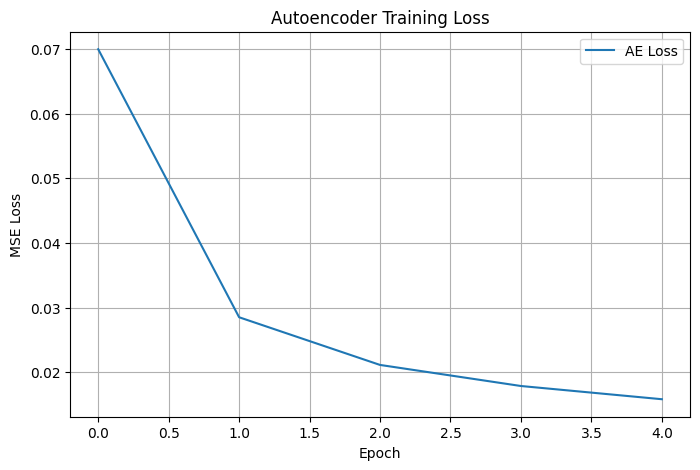

Loss plot saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\ae_loss.png
[Dataset] Loaded 100 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 12 | Batch size: 8


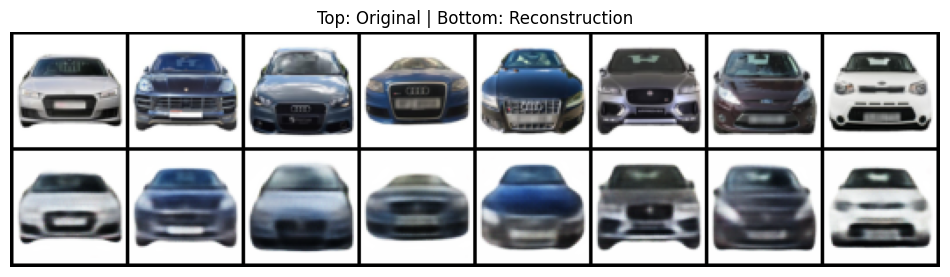

Reconstruction saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\ae_reconstruction.png


In [8]:
from train_ae import train_autoencoder, plot_losses, show_reconstructions

ae_model, ae_losses = train_autoencoder()

plot_losses(ae_losses)
show_reconstructions(ae_model)

[Dataset] Loaded 61827 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 966 | Batch size: 64

Starting WGAN-GP Training...



Epoch [1/5]:   0%|          | 0/966 [00:00<?, ?it/s]d:\Amritha\Deep Learning - 4\SCAFFOLD_R3\DLR3\Lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch [1/5]: 100%|██████████| 966/966 [04:28<00:00,  3.59it/s, critic_loss=-12.8, gen_loss=39.5]  


Epoch [1] G Loss: 39.5191, C Loss: -12.7765


Epoch [2/5]: 100%|██████████| 966/966 [04:22<00:00,  3.69it/s, critic_loss=-207, gen_loss=381]    


Epoch [2] G Loss: 380.9025, C Loss: -206.9077


...

Epoch [3] G Loss: 494.4319, C Loss: -661.4111


Epoch [4/5]: 100%|██████████| 966/966 [04:26<00:00,  3.62it/s, critic_loss=-2.02e+3, gen_loss=1.28e+3] 


Epoch [4] G Loss: 1280.9993, C Loss: -2016.0483


Epoch [5/5]: 100%|██████████| 966/966 [04:25<00:00,  3.63it/s, critic_loss=-829, gen_loss=2.95e+3]     


Epoch [5] G Loss: 2951.8853, C Loss: -828.9792

GAN Training Complete.


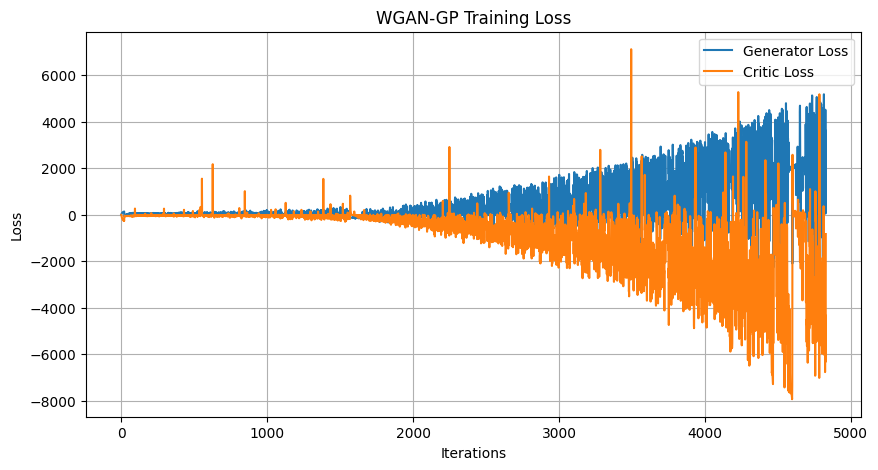

Loss plot saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\gan_loss.png


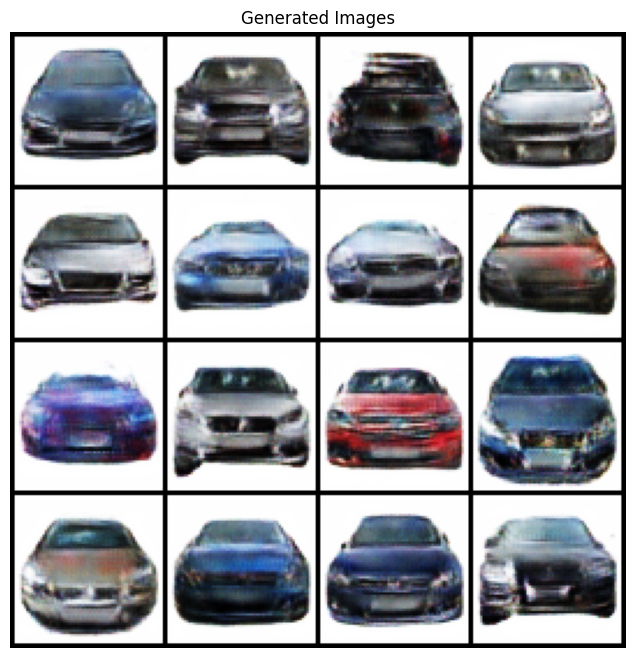

Generated images saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\gan_samples.png


In [9]:
from train_gan import train_gan, plot_gan_losses, generate_samples

gen, critic, gen_losses, critic_losses = train_gan()

plot_gan_losses(gen_losses, critic_losses)
generate_samples(gen)

In [13]:
import importlib
import evaluate
importlib.reload(evaluate)
from evaluate import load_models, extract_latents, plot_pca, plot_tsne, compute_fid


Models loaded successfully.
[Dataset] Loaded 2000 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 31 | Batch size: 64
Running PCA...


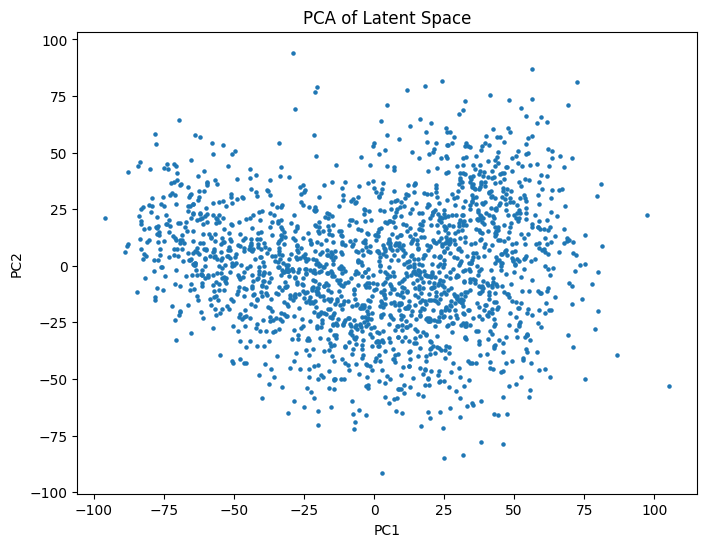

PCA saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\pca.png
Running t-SNE (this may take time)...


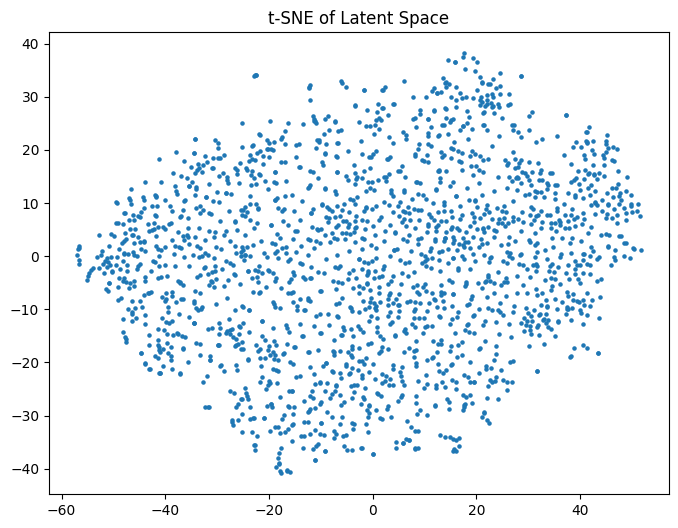

t-SNE saved at: D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\R3_DL_DVMCar\outputs\tsne.png


In [14]:
from evaluate import load_models, extract_latents, plot_pca, plot_tsne, compute_fid

encoder, generator = load_models()

latents, labels = extract_latents(encoder)

plot_pca(latents, labels)
plot_tsne(latents, labels)

In [16]:
from evaluate import generate_fid_images
from dataset import get_dataloader
import matplotlib.pyplot as plt
import os

real_dir = os.path.join(config.OUTPUT_DIR, "real_images")
fake_dir = os.path.join(config.OUTPUT_DIR, "fake_images")

# Save real images for FID comparison
print("Preparing real images for FID...")
loader, _ = get_dataloader(batch_size=1, max_images=config.FID_NUM_SAMPLES)
os.makedirs(real_dir, exist_ok=True)
for i, (img, _) in enumerate(loader):
    img = (img.squeeze(0) + 1) / 2
    plt.imsave(os.path.join(real_dir, f"{i}.png"), img.permute(1, 2, 0).numpy())

# Generate fake images
generate_fid_images(generator, fake_dir, config.FID_NUM_SAMPLES)

# Compute FID
compute_fid(real_dir, fake_dir)


Preparing real images for FID...
[Dataset] Loaded 1000 images from D:\Amritha\Deep Learning - 4\SCAFFOLD_R3\Dataset\car_fronts
[DataLoader] Batches: 1000 | Batch size: 1
Computing FID score...


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to C:\Users\tanus/.cache\torch\hub\checkpoints\pt_inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:48<00:00, 1.95MB/s]
100%|██████████| 32/32 [00:10<00:00,  3.01it/s]


FID Score: 162.51


162.51324616456085